In [1]:
from pylib.preamble import *
enable_autoreload()

from pylib.fig_setup import PALETTE, STYLE, LW, style_ax, legend, country_handles

*`1. indlæs data`*

*Indlæser kombineret datasæt med elektrificeringsandele og energivægte fra parquet og filtrerer til analyseländer og -sektorer.*

In [2]:
# 1. load data
df = pd.read_parquet("0_intermediate/df.parquet")

countries = [g for g in var_groups.countries if g not in {'UK', 'ES'}]

_excl    = {'FC_OTH_NSP_E', 'FC_TRA_NSP_E', 'FC_TRA_DAVI_E', 'FC_TRA_DNAVI_E'}
subs_enw = [s for s in var_groups.subs if s not in _excl]

df = df[df.nrg_bal.isin(subs_enw) & df.geo.isin(countries)].copy()

*`2. energiandele`*

Sektor $i$'s andel af samlet energiforbrug for land $c$ i år $t$:

$$s_{i,c,t} = \frac{\text{Energi}_{i,c,t}}{\displaystyle\sum_j \text{Energi}_{j,c,t}}$$

In [3]:
# 2. energy_shares()
def energy_shares(df_slice):
    g = df_slice.set_index('nrg_bal')['energy_tj'].fillna(0).reindex(subs_enw, fill_value=0)
    e = df_slice.set_index('nrg_bal')['elec_share_pct'].fillna(0).reindex(subs_enw, fill_value=0)
    total = g.sum()
    s = g / total if total > 0 else g.copy()
    return s, e

*`energy_tj` er det totale energiforbrug fra alle kilder — elektricitet, gas, olie, varme, biomasse — målt i TJ.*

*`3. dekomponering`*

Elektrificeringsraten $E_{c,t} = \sum_i s_{i,c,t} \cdot e_{i,c,t}$. Med midtvejsvægte $\bar{s}_i = \tfrac{s_{i,0}+s_{i,1}}{2}$, $\bar{e}_i = \tfrac{e_{i,0}+e_{i,1}}{2}$ gælder eksakt uden residual:

$$\Delta E = \underbrace{\sum_i \Delta s_i \cdot \bar{e}_i}_{\text{sammensætningseffekt}} + \underbrace{\sum_i \bar{s}_i \cdot \Delta e_i}_{\text{intensitetseffekt}} = E_1 - E_0$$

In [4]:
# 3. decompose()
def decompose(s0, s1, e0, e1):
    s_bar, e_bar = (s0 + s1) / 2, (e0 + e1) / 2
    ds, de = s1 - s0, e1 - e0
    return pd.Series({
        'composition': (ds * e_bar).sum(),
        'intensity':   (s_bar * de).sum(),
    })

*`4. tidsserie: dekomponering`*

*For hvert land dekomponeres ændringen fra første til seneste observation i sammensætnings- og intensitetseffekt med midtvejsvægte.*

In [5]:
# 4. tidsserie dekomponering
rows = []
for geo in countries:
    sub = df[df.geo == geo]
    years = sorted(sub.year.unique())
    y0, y1 = years[0], years[-1]
    s0, e0 = energy_shares(sub[sub.year == y0])
    s1, e1 = energy_shares(sub[sub.year == y1])
    res = decompose(s0, s1, e0, e1)
    res['geo'] = geo
    res['y0']  = y0
    res['y1']  = y1
    res['E0']  = (s0 * e0).sum()
    res['E1']  = (s1 * e1).sum()
    rows.append(res)

df_time = pd.DataFrame(rows).set_index('geo')
df_time['total'] = df_time[['composition', 'intensity']].sum(axis=1)
df_time[['y0', 'y1', 'E0', 'E1', 'composition', 'intensity', 'total']].round(2)

,y0,y1,E0,E1,composition,intensity,total
geo,,,,,,,
DK,1995,2023,19.10,20.47,-1.32,2.69,1.37
SE,1995,2023,32.07,35.06,-0.08,3.07,2.99
DE,1995,2023,18.88,21.74,-0.20,3.06,2.86
NL,1995,2023,14.87,23.23,-0.03,8.39,8.36
FR,1995,2023,21.91,26.84,-1.52,6.45,4.93
FI,1995,2023,27.57,28.87,4.16,-2.86,1.29
EU27_2020,1995,2023,19.12,23.23,-1.42,5.53,4.11


*`5. figur: tidslig dekomponering`*

*Stablede søjler over sammensætnings- og intensitetseffekt pr. land, med samlet $\Delta E$ som scatter.*

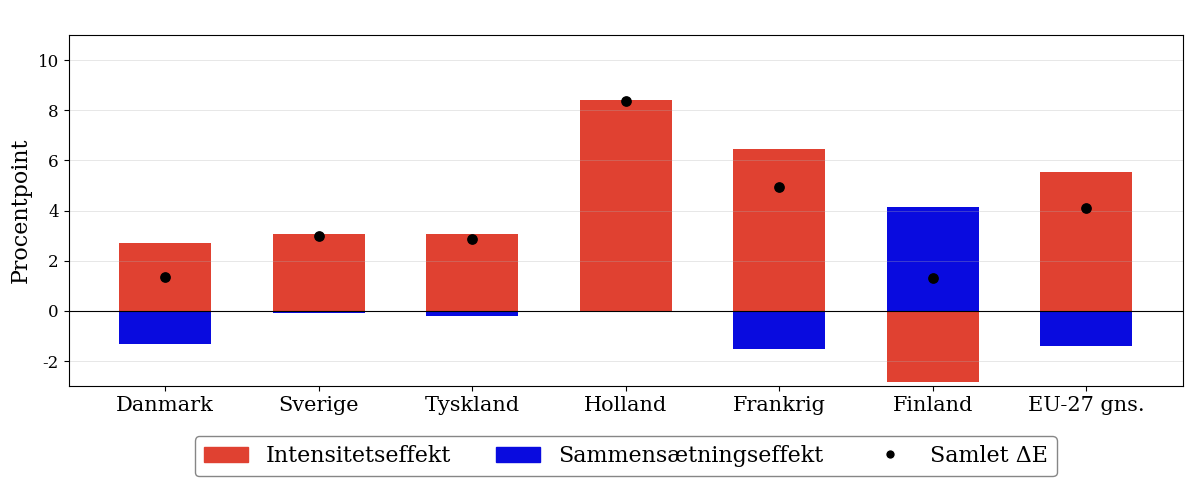

In [6]:
# 5. figur: tidslig dekomponering
_COMP_COLORS = {
    'intensity':   PALETTE['DK'],
    'composition': PALETTE['FR'],
}
_COMP_LABELS = {
    'intensity':   'Intensitetseffekt',
    'composition': 'Sammensætningseffekt',
}

def stacked_decomp_bars(ax, x, df_res, components=('intensity', 'composition')):
    bottom_pos = np.zeros(len(x))
    bottom_neg = np.zeros(len(x))
    patches = []
    for comp in components:
        v = df_res[comp].to_numpy()
        p = np.where(v > 0, v, 0)
        n = np.where(v < 0, v, 0)
        ax.bar(x, p, bottom=bottom_pos, color=_COMP_COLORS[comp], width=0.6)
        ax.bar(x, n, bottom=bottom_neg, color=_COMP_COLORS[comp], width=0.6)
        bottom_pos += p
        bottom_neg += n
        patches.append(Patch(color=_COMP_COLORS[comp], label=_COMP_LABELS[comp]))
    return patches


geos = df_time.index.tolist()
x = np.arange(len(geos))

fig, ax = plt.subplots(figsize=(12, 5))

patches = stacked_decomp_bars(ax, x, df_time)
ax.scatter(x, (df_time['E1'] - df_time['E0']).to_numpy(), color='black', zorder=5, s=45,
           label='Samlet ΔE')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([var_groups.country_names[g] for g in geos], ha='center')
ax.set_ylabel('Procentpoint')
ax.set_ylim(-3,11)
ax.set_title(' ')
ax.grid(axis='y', linewidth=0.6, alpha=0.35)
ax.legend(handles=patches + [plt.Line2D([0],[0], marker='o', color='w',
          markerfacecolor='black', markersize=7, label='Samlet ΔE')],
          frameon=True, framealpha=0.95, edgecolor='0.5', fancybox=True,
          loc='center', ncols=3, bbox_to_anchor=(0.5,-0.2))
plt.tight_layout()
plt.show()

*`6. tværsnit: dekomponering`*

*DK, SE, DE, NL, FR, FI dekomponeres mod EU-27 i det seneste fælles år.*

In [7]:
# 6. tværsnit dekomponering
ref = 'EU27_2020'
eu_years = set(df[df.geo == ref].year.unique())

rows_cross = []
for geo in countries:
    if geo == ref:
        continue
    sub = df[df.geo == geo]
    common_years = sorted(eu_years & set(sub.year.unique()))
    if not common_years:
        continue
    t = common_years[-1]

    s_eu, e_eu = energy_shares(df[(df.geo == ref) & (df.year == t)])
    s_c,  e_c  = energy_shares(sub[sub.year == t])
    res = decompose(s_eu, s_c, e_eu, e_c)
    res['geo']  = geo
    res['year'] = t
    res['E_eu'] = (s_eu * e_eu).sum()
    res['E_c']  = (s_c  * e_c).sum()
    rows_cross.append(res)

df_cross = pd.DataFrame(rows_cross).set_index('geo')
df_cross['total'] = df_cross[['composition', 'intensity']].sum(axis=1)
df_cross[['year', 'E_eu', 'E_c', 'composition', 'intensity', 'total']].round(2)

,year,E_eu,E_c,composition,intensity,total
geo,,,,,,
DK,2023,23.23,20.47,-1.11,-1.65,-2.76
SE,2023,23.23,35.06,1.92,9.91,11.83
DE,2023,23.23,21.74,1.77,-3.26,-1.49
NL,2023,23.23,23.23,1.15,-1.14,0.00
FR,2023,23.23,26.84,-0.78,4.40,3.62
FI,2023,23.23,28.87,2.64,3.01,5.64


*`7. figur: tværsnit dekomponering`*

*Stablede søjler med sammensætnings- og intensitetseffekt pr. land relativt til EU-27.*

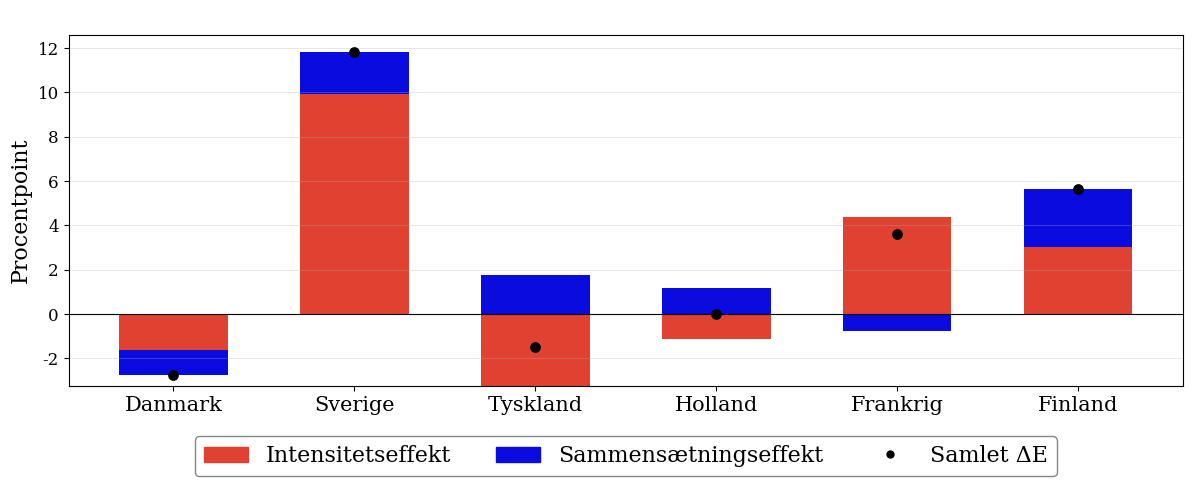

In [8]:
# 7. figur: tværsnit dekomponering
t_cross = int(df_cross['year'].iloc[0])

geos_cross = df_cross.index.tolist()
x = np.arange(len(geos_cross))

fig, ax = plt.subplots(figsize=(12, 5))

patches = stacked_decomp_bars(ax, x, df_cross)
ax.scatter(x, (df_cross['E_c'] - df_cross['E_eu']).to_numpy(),
           color='black', zorder=5, s=45)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([var_groups.country_names[g] for g in geos_cross], ha='center')
ax.set_ylabel('Procentpoint')
ax.set_title(f' ')
ax.grid(axis='y', linewidth=0.6, alpha=0.35)
ax.legend(handles=patches + [plt.Line2D([0],[0], marker='o', color='w',
          markerfacecolor='black', markersize=7, label='Samlet ΔE')],
          frameon=True, framealpha=0.95, edgecolor='0.5', fancybox=True,
          loc='center', ncols=3, bbox_to_anchor=(0.5,-0.2))
plt.tight_layout()
plt.show()

*`8. vækstbidragstabeller`*

*For hvert land opgøres de sektorbidrag, der tilsammen udgør henholdsvis intensitets- og sammensætningseffekten fra Analyse 1. Bidragene er de uaggregerede led i dekomponeringen:*

$$\text{Intensitetsbidrag}_i = \bar{s}_i \cdot \Delta e_i, \qquad \text{Sammensætningsbidrag}_i = \Delta s_i \cdot \bar{e}_i$$

*Sum-rækken svarer eksakt til de tilsvarende kolonner i `df_time`.*

In [9]:
# 8. sector contributions to time-series decomposition
contrib_int  = {}
contrib_comp = {}

for geo in countries:
    sub    = df[df.geo == geo]
    yrs    = sorted(sub.year.unique())
    y0, y1 = yrs[0], yrs[-1]
    s0, e0 = energy_shares(sub[sub.year == y0])
    s1, e1 = energy_shares(sub[sub.year == y1])
    s_bar  = (s0 + s1) / 2
    e_bar  = (e0 + e1) / 2
    ds, de = s1 - s0, e1 - e0
    contrib_int[geo]  = s_bar * de
    contrib_comp[geo] = ds * e_bar

tbl_int  = pd.DataFrame(contrib_int)
tbl_comp = pd.DataFrame(contrib_comp)

_slabels = {s: var_groups.labels[s] for s in subs_enw}
_clabels = {g: var_groups.country_names[g] for g in countries}
tbl_int.rename( index=_slabels, columns=_clabels, inplace=True)
tbl_comp.rename(index=_slabels, columns=_clabels, inplace=True)

tbl_int.loc['Sum']  = tbl_int.sum()
tbl_comp.loc['Sum'] = tbl_comp.sum()

def _style_tbl(tbl, caption):
    data_rows = tbl.index[:-1]
    absmax = max(abs(tbl.loc[data_rows].min().min()),
                 abs(tbl.loc[data_rows].max().max()))
    return (tbl.style
              .format("{:.2f}")
              .set_caption(f"<b>{caption}</b>")
              .background_gradient(cmap='RdYlGn', axis=None,
                                   vmin=-absmax, vmax=absmax,
                                   subset=pd.IndexSlice[data_rows, :])
              .set_properties(subset=pd.IndexSlice[['Sum'], :],
                              **{'font-weight': 'bold', 'border-top': '2px solid black'}))

In [10]:
_style_tbl(tbl_int, "Intensitetseffekt — sektorbidrag (procentpoint)")

,Danmark,Sverige,Tyskland,Holland,Frankrig,Finland,EU-27 gns.
nrg_bal,,,,,,,
Jern og stål,-0.06,-0.02,0.20,-0.05,0.23,1.02,0.42
Kemi og petrokemi,0.17,1.57,-0.35,0.37,-0.32,0.36,0.18
Ikke-jernholdige metaller,0.00,0.03,-0.09,-0.09,0.17,-0.09,-0.02
Ikke-metalliske mineraler,0.22,0.03,0.00,0.06,-0.05,0.28,0.11
Transportudstyr,0.01,0.01,0.03,0.04,-0.23,-0.01,0.02
Maskiner og udstyr,0.06,0.02,0.72,0.25,0.35,0.04,0.40
Minedrift og råstofudvinding,-0.00,-0.04,0.05,0.01,-0.01,0.25,0.04
"Føde-, drikke- og tobaksvarer",0.80,0.14,0.14,0.41,0.28,0.32,0.32
"Papir, papirmasse og trykning",0.14,-1.25,-0.13,0.06,-0.16,-4.49,-0.22


In [11]:
_style_tbl(tbl_comp, "Sammensætningseffekt — sektorbidrag (procentpoint)")

,Danmark,Sverige,Tyskland,Holland,Frankrig,Finland,EU-27 gns.
nrg_bal,,,,,,,
Jern og stål,-0.07,-0.24,-0.12,0.07,-0.46,-0.49,-0.61
Kemi og petrokemi,0.16,-1.40,0.33,0.17,-0.01,-0.23,-0.36
Ikke-jernholdige metaller,0.00,0.11,-0.17,-0.52,-0.20,0.21,-0.15
Ikke-metalliske mineraler,-0.15,-0.10,-0.10,-0.06,-0.02,-0.31,-0.16
Transportudstyr,-0.12,-0.01,-0.03,-0.03,0.16,-0.02,0.04
Maskiner og udstyr,-0.26,-0.27,0.35,-0.12,-0.59,0.16,-0.14
Minedrift og råstofudvinding,-0.01,0.57,-0.10,0.04,0.04,0.16,-0.01
"Føde-, drikke- og tobaksvarer",-0.46,-0.12,0.15,0.07,0.15,-0.10,0.02
"Papir, papirmasse og trykning",-0.25,1.10,0.11,-0.29,-0.19,0.50,0.04
